In [71]:
# !pip install scipy

In [72]:
import numpy as np 
import pandas as pd 
import plot as plot
import load as ld 
import matplotlib.pyplot as plt
import importlib

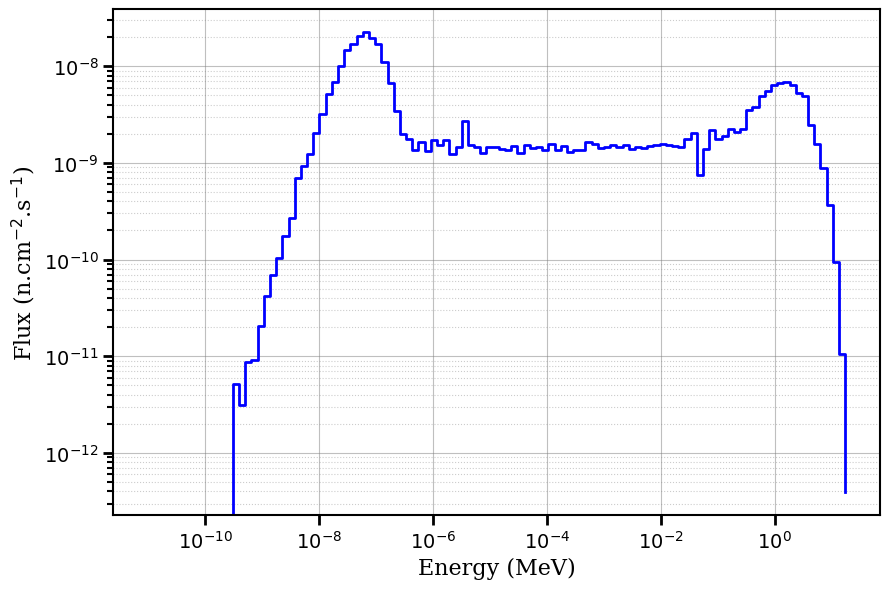

<Axes: xlabel='Energy (MeV)', ylabel='Flux (n.cm$^{-2}$.s$^{-1}$)'>

In [73]:
fonte_watt = ld.load_dados("bh3_car_folhas_ssr.txt.o", 3065, 3168)
plot.plot_flux2(fonte_watt["energy"], fonte_watt["flux"])

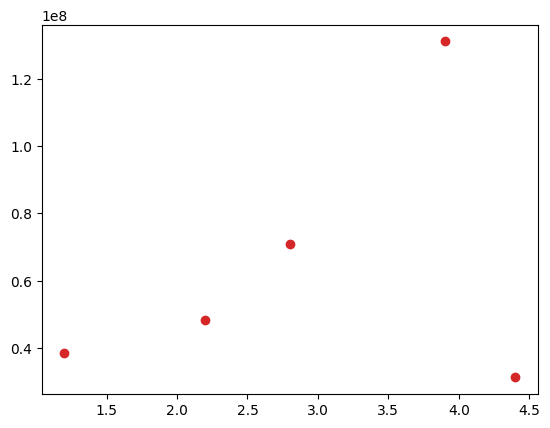

In [74]:
x = np.array([1.20,2.20,2.80,3.90,4.40]) # MeV
y = np.array([3.86E+07,4.83E+07,7.08E+07, 1.31E+08, 3.13E+07])


fig, ax = plt.subplots()
ax.plot(x,y,'o', color='tab:red') 

a = 0.199
b = 251.936
C = 742.284


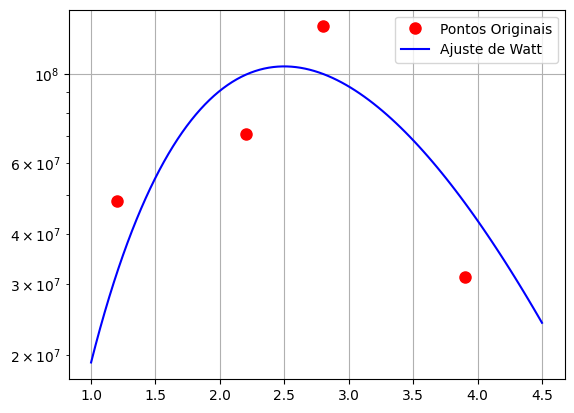

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. 4 pontos pra energia (X) e 4 pontos pro fluxo (Y)
x = np.array([1.20, 2.20, 2.80, 3.90])
y = np.array([4.83E+07, 7.08E+07, 1.31E+08, 3.13E+07])

# 2. A Fórmula
def espectro_watt(E, C, a, b):
    return C * np.exp(-E / a) * np.sinh(np.sqrt(b * E))

# 3. O ajuste
# p0 = [Constante_Alavanca, parâmetro a, parâmetro b]
popt, _ = curve_fit(espectro_watt, x, y, p0=[1e8, 0.988, 2.249])

C_opt, a_opt, b_opt = popt
print(f"a = {a_opt:.3f}")
print(f"b = {b_opt:.3f}")
print(f"C = {C_opt:.3f}")

# 4. Plota os 4 pontos
plt.figure()
plt.plot(x, y, 'o', color='red', markersize=8, label='Pontos Originais')

# 5. Plota a linha gerada pela equação preenchendo o vazio entre eles
x_linha = np.linspace(1.0, 4.5, 100)
y_linha = espectro_watt(x_linha, C_opt, a_opt, b_opt)
plt.plot(x_linha, y_linha, '-', color='blue', label='Ajuste de Watt')

plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()


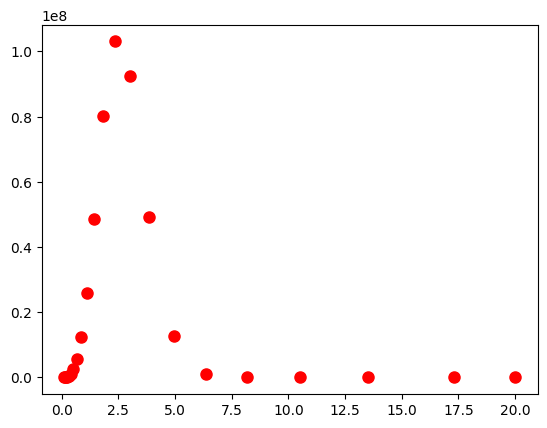

In [76]:
fast_energy = np.array([
    1.17E-01, 1.50E-01, 1.93E-01, 2.47E-01, 3.18E-01, 4.08E-01, 5.23E-01, 6.72E-01,
    8.63E-01, 1.11E+00, 1.42E+00, 1.83E+00, 2.35E+00, 3.01E+00, 3.87E+00, 4.97E+00, 6.38E+00,
    8.19E+00, 1.05E+01, 1.35E+01, 1.73E+01, 2.00E+01
])

flux = espectro_watt(fast_energy, C_opt, a_opt, b_opt)
plt.figure()
plt.plot(fast_energy, flux, 'o', color='red', markersize=8, label='Pontos')

In [77]:
def maxwelliana(C, E):
    T = 290 
    k = 8.617333e-11 # Constante de Boltzmann em MeV/K
    kT = k * T 
    return C * ((E / kT)**2) * np.exp(-E / kT)

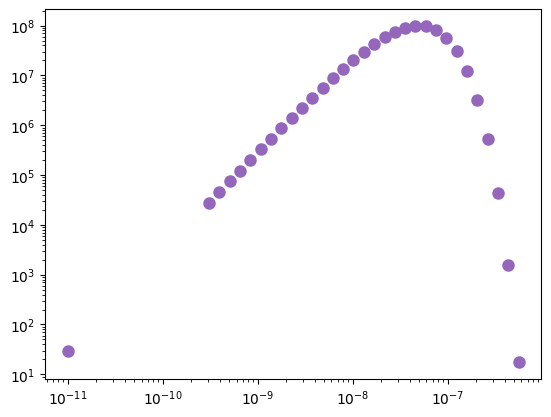

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Calcular a fórmula Maxwelliana
energias_termicas = np.array([
    1.00e-11, 3.09e-10, 3.97e-10, 5.10e-10, 6.54e-10, 8.40e-10, 1.08e-09,
    1.39e-09, 1.78e-09, 2.28e-09, 2.93e-09, 3.77e-09, 4.84e-09, 6.21e-09,
    7.97e-09, 1.02e-08, 1.31e-08, 1.69e-08, 2.17e-08, 2.78e-08, 3.57e-08,
    4.59e-08, 5.89e-08, 7.56e-08, 9.71e-08, 1.25e-07, 1.60e-07, 2.06e-07,
    2.64e-07, 3.39e-07, 4.35e-07, 5.59e-07
])
f_E = maxwelliana(1.84E+8,energias_termicas)


plt.figure()
plt.plot(energias_termicas, f_E, 'o', color='tab:purple', markersize=8, label='Pontos')
plt.xscale('log') 
plt.yscale('log')

a = -1.141
lamb = 7.371e+05


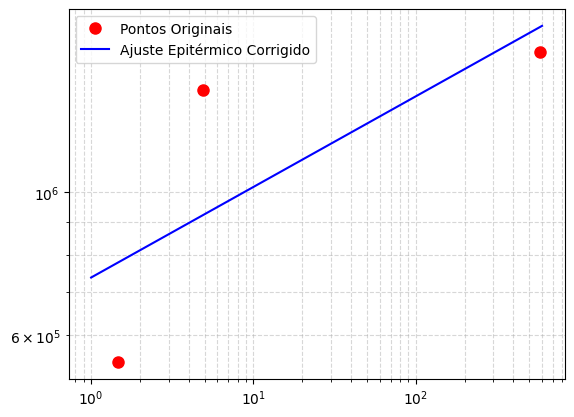

In [92]:
# 3. O Ajuste Otimizado (Blindado trabalhando com LOGs)
def log_epitermico(E, log_lamb, a):
    # Aplicamos as propriedades de Log para linearizar a sua equação original
    return log_lamb - (1 + a) * np.log(E)

# Avisamos o curve_fit para olhar apenas para o np.log(y)
# P0: [log do primeiro y, 'a' no campo negativo para forçar subida]
popt, _ = curve_fit(log_epitermico, x, np.log(y), p0=[np.log(5.45E5), -1.5])

log_lamb_opt, alfa_opt = popt
# Convertendo o log_lamb de volta para o Lambda milionario original:
lamb_opt = np.exp(log_lamb_opt)

print(f"a = {alfa_opt:.3f}")
print(f"lamb = {lamb_opt:.3e}")


# =======================================================
# NADA MUDA DAQUI PARA BAIXO, PODE CONTINUAR COM A SUA FUNÇÃO
# A reta vai usar os novos parâmetros mágicos e cruzar os pontos!
plt.figure()
plt.plot(x, y, 'o', color='red', markersize=8, label='Pontos Originais', zorder=5)

x_linha = np.logspace(np.log10(1.0), np.log10(600.0), 100)
# Usa a função `epitermico` original que você já tinha declarado no Passo 2
y_linha = epitermico(x_linha, lamb_opt, alfa_opt)

plt.plot(x_linha, y_linha, '-', color='blue', label='Ajuste Epitérmico Corrigido')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


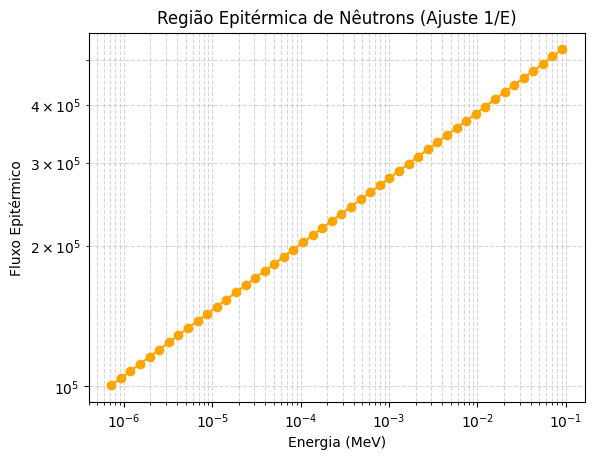

In [93]:

energias_epitermicas =np.array([
    7.18e-07, 9.21e-07, 1.18e-06, 1.52e-06, 1.95e-06, 2.51e-06, 3.22e-06, 
    4.13e-06, 5.30e-06, 6.81e-06, 8.74e-06, 1.12e-05, 1.44e-05, 1.85e-05, 
    2.38e-05, 3.05e-05, 3.92e-05, 5.03e-05, 6.46e-05, 8.29e-05, 1.07e-04, 
    1.37e-04, 1.76e-04, 2.25e-04, 2.90e-04, 3.72e-04, 4.77e-04, 6.13e-04, 
    7.87e-04, 1.01e-03, 1.30e-03, 1.67e-03, 2.14e-03, 2.75e-03, 3.53e-03, 
    4.53e-03, 5.81e-03, 7.47e-03, 9.59e-03, 1.23e-02, 1.58e-02, 2.03e-02, 
    2.61e-02, 3.35e-02, 4.30e-02, 5.52e-02, 7.08e-02, 9.10e-02
])
y_epi = epitermico(energias_epitermicas, lamb_opt,alfa_opt )
# Para Plotar:
import matplotlib.pyplot as plt
plt.plot(energias_epitermicas,y_epi, marker='o', color='orange')
plt.title('Região Epitérmica de Nêutrons (Ajuste 1/E)')
plt.xlabel('Energia (MeV)')
plt.ylabel('Fluxo Epitérmico')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
# A região epitérmica DEVE ser olhada em log-log!
plt.xscale('log')
plt.yscale('log')
plt.show()

In [96]:
X_total = np.array([
    1.00e-11, 3.09e-10, 3.97e-10, 5.10e-10, 6.54e-10, 8.40e-10, 1.08e-09,
    1.39e-09, 1.78e-09, 2.28e-09, 2.93e-09, 3.77e-09, 4.84e-09, 6.21e-09,
    7.97e-09, 1.02e-08, 1.31e-08, 1.69e-08, 2.17e-08, 2.78e-08, 3.57e-08,
    4.59e-08, 5.89e-08, 7.56e-08, 9.71e-08, 1.25e-07, 1.60e-07, 2.06e-07,
    2.64e-07, 3.39e-07, 4.35e-07, 5.59e-07, 7.18e-07, 9.21e-07, 1.18e-06,
    1.52e-06, 1.95e-06, 2.51e-06, 3.22e-06, 4.13e-06, 5.30e-06, 6.81e-06,
    8.74e-06, 1.12e-05, 1.44e-05, 1.85e-05, 2.38e-05, 3.05e-05, 3.92e-05,
    5.03e-05, 6.46e-05, 8.29e-05, 1.07e-04, 1.37e-04, 1.76e-04, 2.25e-04,
    2.90e-04, 3.72e-04, 4.77e-04, 6.13e-04, 7.87e-04, 1.01e-03, 1.30e-03,
    1.67e-03, 2.14e-03, 2.75e-03, 3.53e-03, 4.53e-03, 5.81e-03, 7.47e-03,
    9.59e-03, 1.23e-02, 1.58e-02, 2.03e-02, 2.61e-02, 3.35e-02, 4.30e-02,
    5.52e-02, 7.08e-02, 9.10e-02, 1.17e-01, 1.50e-01, 1.93e-01, 2.47e-01,
    3.18e-01, 4.08e-01, 5.23e-01, 6.72e-01, 8.63e-01, 1.11e+00, 1.42e+00,
    1.83e+00, 2.35e+00, 3.01e+00, 3.87e+00, 4.97e+00, 6.38e+00, 8.19e+00,
    1.05e+01, 1.35e+01, 1.73e+01, 2.00e+01
])

y_total = np.concatenate((f_E,y_epi,flux))

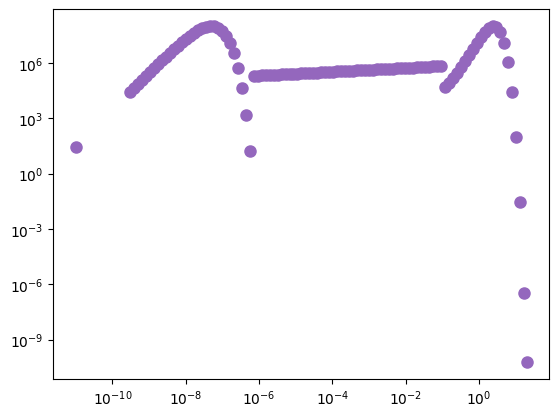

In [94]:
plt.figure()
plt.plot(X_total, y_total, 'o', color='tab:purple', markersize=8, label='Pontos')
plt.xscale('log') 
plt.yscale('log')

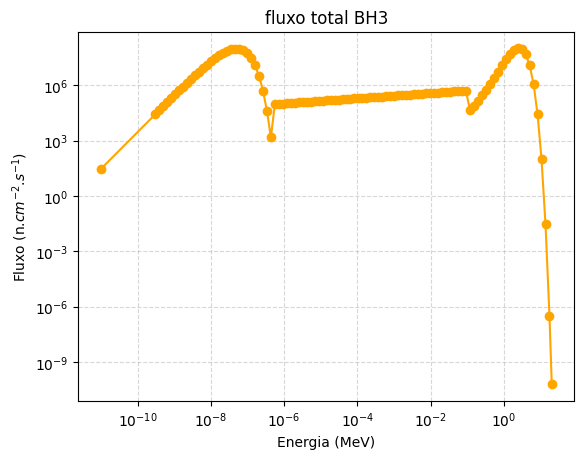

In [97]:
# energia recebida em eV
def flux_total_bh3(x):
    # 1. Cria uma lista vazia do exato mesmo tamanho e formato de X (cheia de zeros)
    y_total = np.zeros_like(x)
    
    # 2. SEPARAÇÃO PELOS LIMITES (Tudo em eV)
    # 0 a 0.5 eV (Térmico)
    # 0.5 eV a 100,000 eV (Epitérmico)
    # > 100,000 eV (Rápido)
    
    # MÁSCARAS: Descobrem as posições exatas dos números no array que obedecem a regra
    mascara_termica = (x*1E+6 < 0.5)
    mascara_epi = (x*1E+6 >= 0.5) & (x*1E+6 <= 100000.0) # Atenção: No array tem que usar & em vez de 'and'
    mascara_rapida = (x*1E+6 > 100000.0)
    
    # 3. APLICA AS FUNÇÕES NOS LOCAIS CERTOS
    # Ele pega a função, injeta A NELA APENAS o pedaço de 'X' filtrado,
    # e grava o resultado EXATAMENTE no lugar dos zeros de 'y_total'
    
    # Cálculo Térmico
    y_total[mascara_termica] = maxwelliana(1.84E+8, x[mascara_termica])
    
    # Cálculo Epitérmico
    y_total[mascara_epi] = epitermico(x[mascara_epi], lamb_opt, alfa_opt)
    
    # Cálculo Rápido de Watt
    y_total[mascara_rapida] = espectro_watt(x[mascara_rapida], C_opt, a_opt, b_opt)

    # Devolve a array perfeita, sem precisar de if/else nem de concatenate!
    return y_total

# Testando!
flux_total = flux_total_bh3(X_total)
# print(flux_total)


plt.plot(X_total,flux_total, marker='o', color='orange')
plt.title('fluxo total BH3')
plt.xlabel('Energia (MeV)')
plt.ylabel('Fluxo (n.$cm^{-2}$.$s^{-1}$)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
# A região epitérmica DEVE ser olhada em log-log!
plt.xscale('log')
plt.yscale('log')
plt.show()

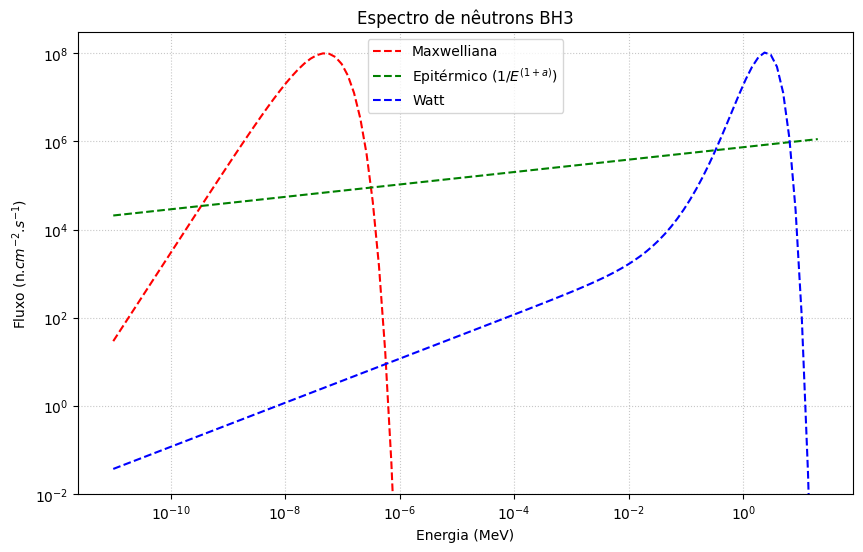

In [98]:
plt.figure(figsize=(10, 6))

# Plota AS TRÊS FÍSICAS completas sobre todo o domínio de energia (sem dar máscaras!)
y_term_full = maxwelliana(1.84E+8, X_total)
y_epi_full = epitermico(X_total, lamb_opt, alfa_opt)
y_watt_full = espectro_watt(X_total, C_opt, a_opt, b_opt)

# Desenhamos cada espectro puro para ver de onde até onde eles dominam
plt.plot(X_total, y_term_full, '--', color='red', label='Maxwelliana')
plt.plot(X_total, y_epi_full, '--', color='green', label='Epitérmico (1/$E^{(1+a)}$)')
plt.plot(X_total, y_watt_full, '--', color='blue', label='Watt')

# Aqui pode ser super útil plotar também o FLUXO BRUTO DO MCNP 
# Exemplo se existir: plt.plot(X_total, array_flux_mcnp_cru, 'k', label='Dados Originais MCNP')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-2, 3e8)

plt.title('Espectro de nêutrons BH3')
plt.xlabel('Energia (MeV)')
plt.ylabel('Fluxo (n.$cm^{-2}$.$s^{-1}$)')
plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.legend()
plt.show()


--- Físicas Limitadoras ---
Corte 1 (Term -> Epi): 3.1768e-07 MeV
Corte 2 (Epi -> Watt): 3.2720e-01 MeV


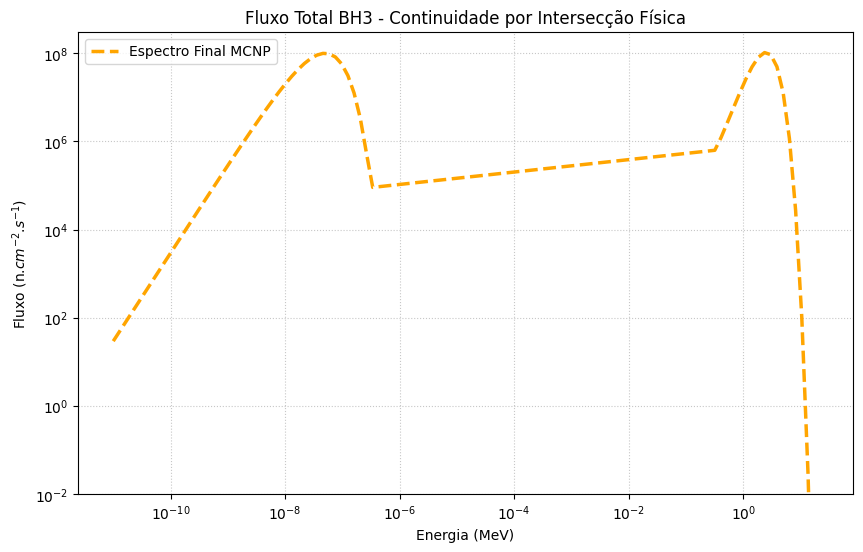

In [99]:
from scipy.optimize import fsolve

# 1. Funções que calculam a "diferença" de altura entre as curvas
# (Quando a diferença for ZERO, encontramos o cruzamento exato)
def encontro_term_epi(E):
    return maxwelliana(1.84E+8, E) - epitermico(E, lamb_opt, alfa_opt)

def encontro_epi_watt(E):
    return epitermico(E, lamb_opt, alfa_opt) - espectro_watt(E, C_opt, a_opt, b_opt)

# 2. Mandamos o Python resolver a equação. 
# x0 é só um "chute inicial" do eixo X olhando de onde as linhas se interceptam no seu gráfico
corte_1 = fsolve(encontro_term_epi, x0=1e-7)[0]
corte_2 = fsolve(encontro_epi_watt, x0=1.0)[0]

# Mostre onde os limites físicos foram definidos pelo cruzamento
print(f"--- Físicas Limitadoras ---")
print(f"Corte 1 (Term -> Epi): {corte_1:.4e} MeV")
print(f"Corte 2 (Epi -> Watt): {corte_2:.4e} MeV")

# ==============================================================================

# 3. Agora nossa função de Plotagem fica estupidamente limpa e os
# dados do MCNP permanecem intocados!
def flux_total_bh3(x):
    y_total = np.zeros_like(x)
    
    # As máscaras agora usam os cortes reais das colisões
    mascara_termica = (x < corte_1)
    mascara_epi = (x >= corte_1) & (x <= corte_2)
    mascara_rapida = (x > corte_2)
    
    # Gravamos as funções puras originais! Elas agora colarão automaticamente
    # pois a transição só ocorre na exata casa decimal em que as duas são idênticas.
    y_total[mascara_termica] = maxwelliana(1.84E+8, x[mascara_termica])
    y_total[mascara_epi] = epitermico(x[mascara_epi], lamb_opt, alfa_opt)
    y_total[mascara_rapida] = espectro_watt(x[mascara_rapida], C_opt, a_opt, b_opt)

    return y_total


# E plotamos!
flux_total = flux_total_bh3(X_total)

plt.figure(figsize=(10, 6))

# Trocado para o formato degraus do MCNP que vc pediu mais cedo
plt.plot(X_total, flux_total,'--', color='orange', linewidth=2.5, label='Espectro Final MCNP')
plt.title('Fluxo Total BH3 - Continuidade por Intersecção Física')
plt.xlabel('Energia (MeV)')
plt.ylabel('Fluxo (n.$cm^{-2}$.$s^{-1}$)')
plt.grid(True, which="both", linestyle=':', alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-2, 3e8)
plt.legend()
plt.show()


In [86]:
y_total

array([2.94511522e+01, 2.77858101e+04, 4.57043784e+04, 7.50850319e+04,
       1.22762579e+05, 2.01018797e+05, 3.29120366e+05, 5.38455103e+05,
       8.69325199e+05, 1.39804994e+06, 2.24953201e+06, 3.60115370e+06,
       5.68662561e+06, 8.86213794e+06, 1.36045978e+07, 2.03805195e+07,
       2.99336526e+07, 4.27909627e+07, 5.82211923e+07, 7.48586669e+07,
       8.99908629e+07, 9.89068079e+07, 9.68077901e+07, 8.17526030e+07,
       5.70502720e+07, 3.09583533e+07, 1.25011130e+07, 3.28874379e+06,
       5.30331943e+05, 4.34858917e+04, 1.53669289e+03, 1.77620251e+01,
       2.01034874e+05, 2.06313389e+05, 2.11704477e+05, 2.17358269e+05,
       2.23068367e+05, 2.29007943e+05, 2.35023584e+05, 2.41192159e+05,
       2.47536382e+05, 2.54080694e+05, 2.60766338e+05, 2.67585715e+05,
       2.74678074e+05, 2.81935762e+05, 2.89426557e+05, 2.96996595e+05,
       3.04856927e+05, 3.12872471e+05, 3.21128213e+05, 3.29574741e+05,
       3.38446759e+05, 3.47266799e+05, 3.56441000e+05, 3.65671517e+05,
      

<>:45: SyntaxWarning: invalid escape sequence '\P'
<>:45: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Carlos\AppData\Local\Temp\ipykernel_11624\3890150537.py:45: SyntaxWarning: invalid escape sequence '\P'
  plt.ylabel('Fluxo $\Phi(E)$', fontsize=12)


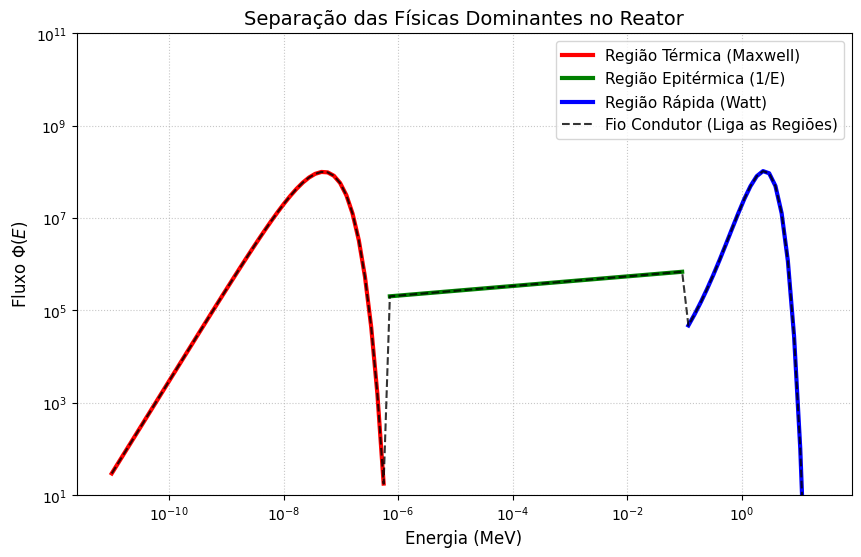

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Calculando os pedaços (usando OS SEUS ARRAYS CURTOS específicos daquela região)
# ==============================================================================
# Térmico (Calculado apenas sobre as 'energias_termicas')
y_term = maxwelliana(1.84E+8, energias_termicas)

# Epitérmico (Calculado apenas sobre as 'energias_epitermicas')
y_epi = epitermico( energias_epitermicas, lamb_opt, alfa_opt)

# Rápido (Calculado apenas sobre a 'fast_energy')
y_watt = espectro_watt(fast_energy, C_opt, a_opt, b_opt)

# ==============================================================================
# 2. O Array "Cola" (Aquele que LIGA TODAS ELAS num fio inquebrável)
# ==============================================================================
# Juntamos as 3 na gaveta 'y_total' pra ter os 121 pontos exatos do 'X_total'
y_total = np.concatenate((y_term, y_epi, y_watt))

# ==============================================================================
# 3. O PLOT MARAVILHOSO
# ==============================================================================
plt.figure(figsize=(10, 6))

# A. Traçamos as 3 coloridas EXATAMENTE onde elas existem fisicamente (Sem dar erro de tamanho!)
plt.plot(energias_termicas, y_term, '-', color='red', linewidth=3, label='Região Térmica (Maxwell)')
plt.plot(energias_epitermicas, y_epi, '-', color='green', linewidth=3, label='Região Epitérmica (1/E)')
plt.plot(fast_energy, y_watt, '-', color='blue', linewidth=3, label='Região Rápida (Watt)')

# B. A LIGAÇÃO! O fio preto tracejado liga por baixo todo o array X_total com o y_total
plt.plot(X_total, y_total, 'k--', linewidth=1.5, label='Fio Condutor (Liga as Regiões)', alpha=0.8)

# Colocando o Log-Log
plt.xscale('log')
plt.yscale('log')

# Limita o teto e o chão do gráfico para evitar visualização das distorções do 1/E no infinito
# (Ajuste o '1e1' pro mínimo que quiser ver, e o '1e10' pro pico que achar ideal)
plt.ylim(1e1, 1e11)  

plt.title('Separação das Físicas Dominantes no Reator', fontsize=14)
plt.xlabel('Energia (MeV)', fontsize=12)
plt.ylabel('Fluxo $\Phi(E)$', fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.show()
